<a href="https://colab.research.google.com/github/sumitsingh63/EAA_Project/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Exploratory Data Analysis

## Panchang-Based Astronomical Indicators Against Historical Weather Trends

### Objective

This notebook performs a comprehensive exploratory analysis of the integrated
1901–2025 daily rainfall and astronomical/Nakshatra dataset.

The analysis investigates:

- Historical rainfall characteristics
- Seasonal and monthly rainfall patterns
- Long-term rainfall variability
- Solar Nakshatra-wise rainfall patterns
- Solar Nakshatra Pada patterns
- Lunar Nakshatra patterns
- Nakshatra × month interactions
- Historical baseline vs recent-period changes
- Extreme rainfall behavior
- Relationships among astronomical and rainfall variables

The findings from this notebook will guide the subsequent statistical
hypothesis testing and machine-learning stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("EDA environment initialized successfully.")

EDA environment initialized successfully.


Loading the Master Dataset

In [2]:
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    "sumitsingh63/EAA_Project/main/data/raw/"
)

IMD_FILE = GITHUB_RAW_BASE + "imd_rainfall_master_1901_2025.csv"
NAKSHATRA_FILE = GITHUB_RAW_BASE + "nakshatra_tags.csv"

imd_df = pd.read_csv(IMD_FILE)
nakshatra_df = pd.read_csv(NAKSHATRA_FILE)

imd_df["Date"] = pd.to_datetime(imd_df["Date"])
nakshatra_df["date"] = pd.to_datetime(nakshatra_df["date"])

master_df = pd.merge(
    imd_df,
    nakshatra_df,
    left_on="Date",
    right_on="date",
    how="inner",
    validate="one_to_one"
)

master_df = master_df.drop(columns=["date"])

print("Master dataset loaded successfully.")
print("Shape:", master_df.shape)

Master dataset loaded successfully.
Shape: (45656, 11)


Creating Analytical Time Variables

In [3]:
master_df["Year"] = master_df["Date"].dt.year
master_df["Month"] = master_df["Date"].dt.month
master_df["Month_Name"] = master_df["Date"].dt.month_name()
master_df["Day"] = master_df["Date"].dt.day
master_df["Day_of_Year"] = master_df["Date"].dt.dayofyear

# Meteorological-style seasons
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

master_df["Season"] = master_df["Month"].apply(assign_season)

# Historical periods
master_df["Era"] = np.where(
    master_df["Year"] <= 1960,
    "Baseline (1901–1960)",
    "Recent (1961–2025)"
)

print("Analytical features created.")

Analytical features created.


Dataset Overview

In [4]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"Observations : {len(master_df):,}")
print(f"Variables    : {master_df.shape[1]}")
print(f"Start date   : {master_df['Date'].min().date()}")
print(f"End date     : {master_df['Date'].max().date()}")
print(f"Years        : {master_df['Year'].nunique()}")
print(f"Nakshatras   : {master_df['solar_nakshatra'].nunique()}")

DATASET OVERVIEW
Observations : 45,656
Variables    : 15
Start date   : 1901-01-01
End date     : 2025-12-31
Years        : 125
Nakshatras   : 27


Data Quality Assessment

In [5]:
quality_report = pd.DataFrame({
    "Data_Type": master_df.dtypes.astype(str),
    "Missing_Count": master_df.isnull().sum(),
    "Missing_Percent": (
        master_df.isnull().mean() * 100
    ).round(3),
    "Unique_Values": master_df.nunique()
})

quality_report

,Data_Type,Missing_Count,Missing_Percent,Unique_Values
Date,datetime64[ns],0,0.0,45656
Year,int32,0,0.0,125
Month,int32,0,0.0,12
Day,int32,0,0.0,31
Rainfall_mm,float64,0,0.0,1569
sun_sidereal_longitude,float64,0,0.0,45383
solar_nakshatra,object,0,0.0,27
solar_nakshatra_pada,int64,0,0.0,4
moon_sidereal_longitude,float64,0,0.0,45374
lunar_nakshatra,object,0,0.0,27


In [6]:
print("Duplicate complete rows:",
      master_df.duplicated().sum())

print("Duplicate dates:",
      master_df["Date"].duplicated().sum())

Duplicate complete rows: 0
Duplicate dates: 0


In [7]:
expected_dates = pd.date_range(
    master_df["Date"].min(),
    master_df["Date"].max(),
    freq="D"
)

actual_dates = pd.DatetimeIndex(
    master_df["Date"]
)

missing_dates = expected_dates.difference(actual_dates)

print("Expected days :", len(expected_dates))
print("Actual days   :", len(actual_dates))
print("Missing days  :", len(missing_dates))

Expected days : 45656
Actual days   : 45656
Missing days  : 0


Descriptive Statistics

In [35]:
rainfall_stats = master_df["Rainfall_mm"].describe()

print("DAILY RAINFALL DESCRIPTIVE STATISTICS")
print("=" * 60)

display(rainfall_stats.to_frame(name="Rainfall_mm"))

DAILY RAINFALL DESCRIPTIVE STATISTICS


,Rainfall_mm
count,45656.000000
mean,3.129317
std,3.483631
min,0.000000
25%,0.450000
50%,1.600000
75%,5.100000
max,19.130000


Additional Statistics

In [9]:
rainfall_additional = pd.Series({
    "Mean": master_df["Rainfall_mm"].mean(),
    "Median": master_df["Rainfall_mm"].median(),
    "Variance": master_df["Rainfall_mm"].var(),
    "Std Dev": master_df["Rainfall_mm"].std(),
    "Skewness": master_df["Rainfall_mm"].skew(),
    "Kurtosis": master_df["Rainfall_mm"].kurtosis(),
    "Minimum": master_df["Rainfall_mm"].min(),
    "Maximum": master_df["Rainfall_mm"].max()
})

display(
    rainfall_additional.to_frame(
        name="Value"
    )
)

,Value
Mean,3.129317
Median,1.600000
Variance,12.135687
Std Dev,3.483631
Skewness,1.259004
Kurtosis,0.722185
Minimum,0.000000
Maximum,19.130000


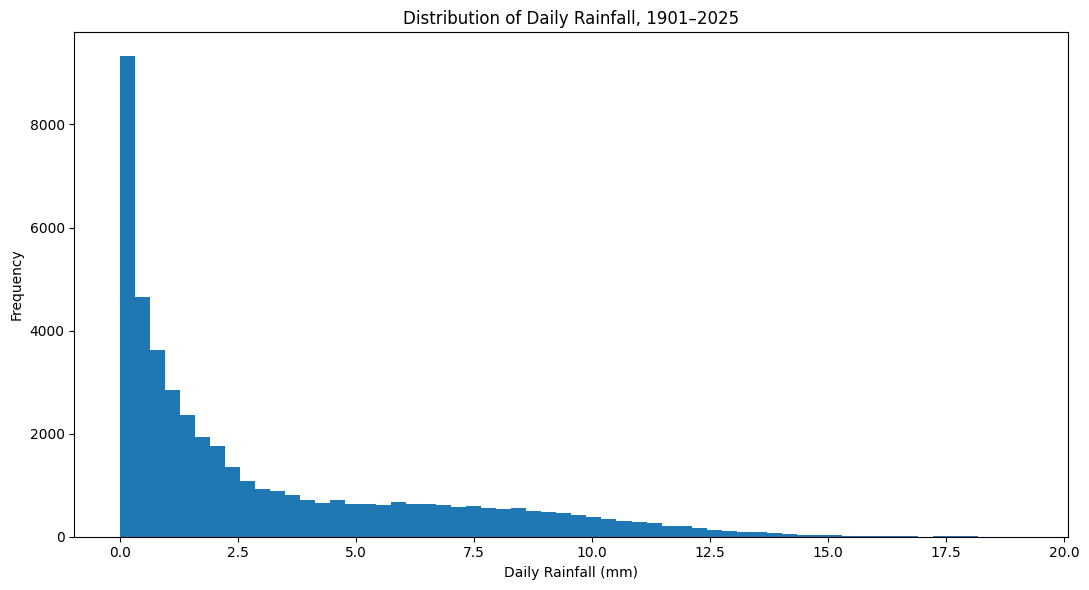

In [10]:
plt.figure(figsize=(11, 6))

plt.hist(
    master_df["Rainfall_mm"],
    bins=60
)

plt.xlabel("Daily Rainfall (mm)")
plt.ylabel("Frequency")
plt.title(
    "Distribution of Daily Rainfall, 1901–2025"
)

plt.tight_layout()
plt.show()

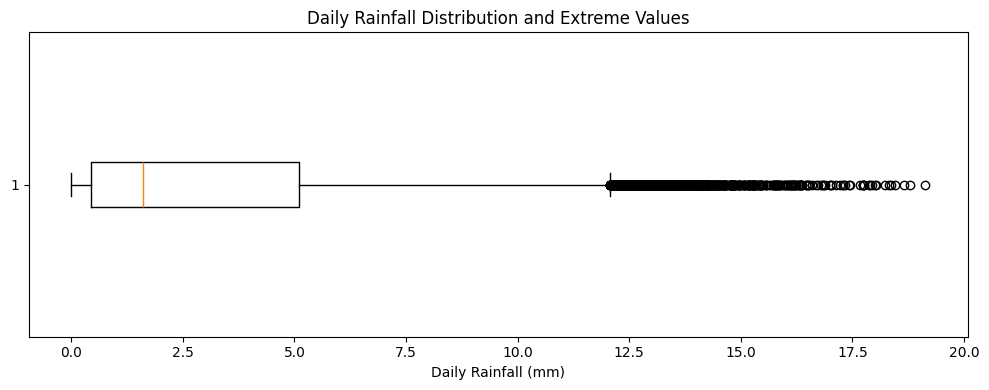

In [11]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    master_df["Rainfall_mm"],
    vert=False
)

plt.xlabel("Daily Rainfall (mm)")
plt.title(
    "Daily Rainfall Distribution and Extreme Values"
)

plt.tight_layout()
plt.show()

## Wet/dry day analysis

In [12]:
master_df["Wet_Day"] = (
    master_df["Rainfall_mm"] > 0
)

wet_days = master_df["Wet_Day"].sum()
dry_days = (~master_df["Wet_Day"]).sum()

wet_dry_summary = pd.DataFrame({
    "Category": ["Wet Days", "Dry Days"],
    "Days": [wet_days, dry_days],
    "Percentage": [
        wet_days / len(master_df) * 100,
        dry_days / len(master_df) * 100
    ]
})

wet_dry_summary["Percentage"] = (
    wet_dry_summary["Percentage"].round(2)
)

wet_dry_summary

,Category,Days,Percentage
0,Wet Days,44755,98.03
1,Dry Days,901,1.97


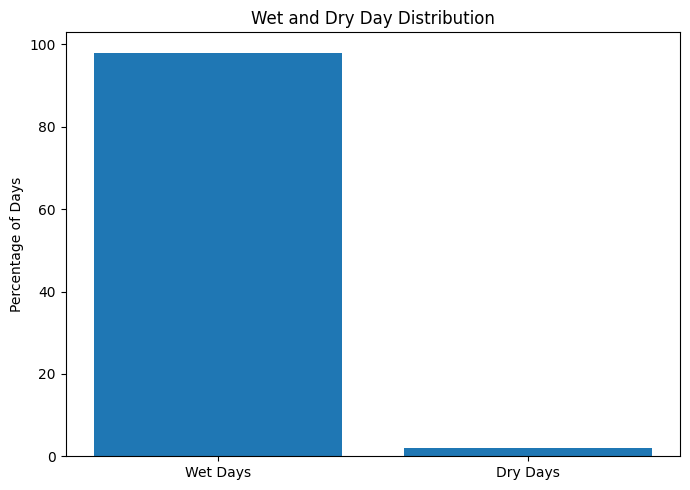

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    wet_dry_summary["Category"],
    wet_dry_summary["Percentage"]
)

plt.ylabel("Percentage of Days")
plt.title("Wet and Dry Day Distribution")

plt.tight_layout()
plt.show()

## Annual Rainfall Analysis

In [14]:
annual_stats = (
    master_df
    .groupby("Year")["Rainfall_mm"]
    .agg(
        Total_Rainfall="sum",
        Mean_Daily_Rainfall="mean",
        Median_Daily_Rainfall="median",
        Std_Dev="std",
        Wet_Days=lambda x: (x > 0).sum(),
        Maximum_Daily_Rainfall="max"
    )
    .reset_index()
)

annual_stats.head()

,Year,Total_Rainfall,Mean_Daily_Rainfall,Median_Daily_Rainfall,Std_Dev,Wet_Days,Maximum_Daily_Rainfall
0,1901,1007.01,2.758932,1.510,3.057060,358,13.69
1,1902,1038.45,2.845068,1.570,3.260519,355,17.88
2,1903,1158.41,3.173726,1.550,3.552225,358,14.17
3,1904,1005.28,2.746667,1.415,3.075516,357,11.69
4,1905,963.72,2.640329,1.420,2.959383,358,13.71


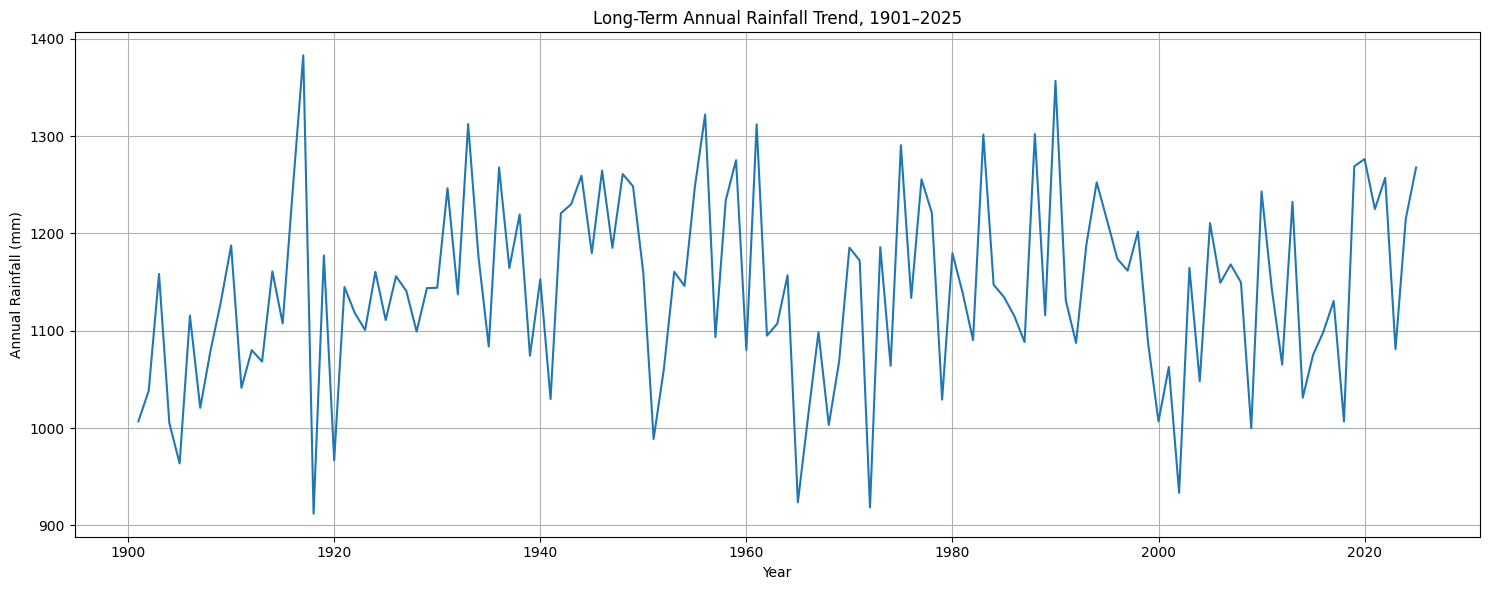

In [15]:
# Annual Rainfall Trend

plt.figure(figsize=(15, 6))

plt.plot(
    annual_stats["Year"],
    annual_stats["Total_Rainfall"]
)

plt.xlabel("Year")
plt.ylabel("Annual Rainfall (mm)")
plt.title(
    "Long-Term Annual Rainfall Trend, 1901–2025"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# Montly Analysis

In [36]:
MONTH_ORDER = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

monthly_stats = (
    master_df
    .groupby("Month")
    .agg(
        Mean_Rainfall=("Rainfall_mm", "mean"),
        Median_Rainfall=("Rainfall_mm", "median"),
        Std_Dev=("Rainfall_mm", "std"),
        Total_Rainfall=("Rainfall_mm", "sum"),
        Wet_Days=("Wet_Day", "sum")
    )
    .reset_index()
)

monthly_stats

,Month,Mean_Rainfall,Median_Rainfall,Std_Dev,Total_Rainfall,Wet_Days
0,1,0.581528,0.26,0.861226,2253.42,3621
1,2,0.755358,0.43,0.971727,2667.17,3414
2,3,0.880377,0.60,0.953203,3411.46,3811
3,4,1.303483,1.10,0.920988,4888.06,3748
4,5,2.041972,1.80,1.240173,7912.64,3875
5,6,5.424469,5.04,2.842485,20341.76,3750
6,7,9.069094,8.99,2.833583,35142.74,3875
7,8,7.982797,7.87,2.610641,30933.34,3875
8,9,5.573733,5.40,2.590591,20901.50,3750
9,10,2.356877,1.80,2.020879,9132.90,3873


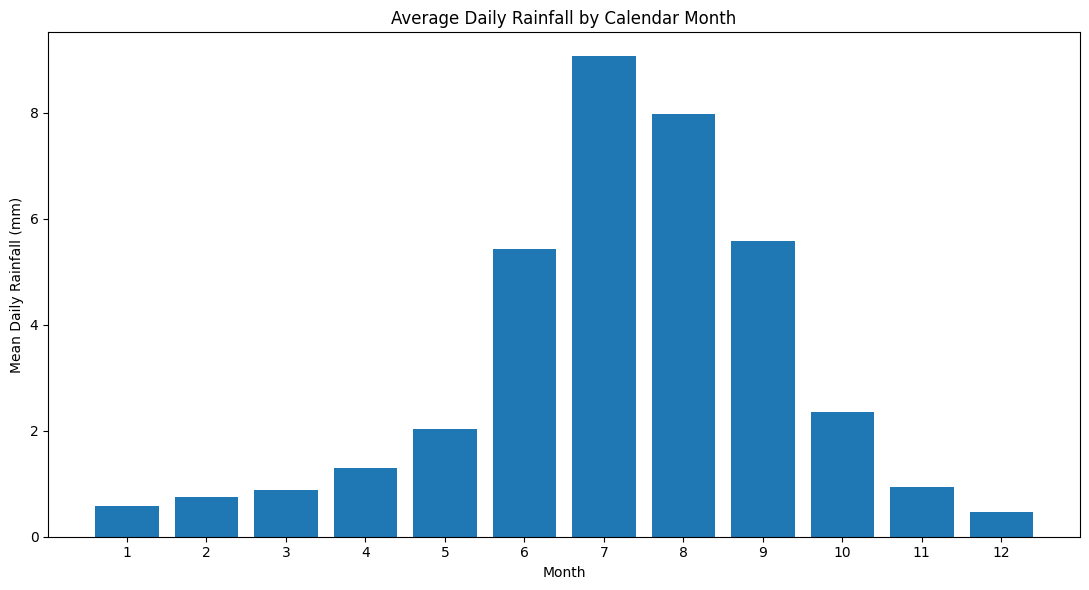

In [37]:
plt.figure(figsize=(11, 6))

plt.bar(
    monthly_stats["Month"],
    monthly_stats["Mean_Rainfall"]
)

plt.xlabel("Month")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.title("Average Daily Rainfall by Calendar Month")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

Seasonal Analysis

In [38]:
season_order = [
    "Winter",
    "Pre-Monsoon",
    "Monsoon",
    "Post-Monsoon"
]

season_stats = (
    master_df
    .groupby("Season")["Rainfall_mm"]
    .agg(
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Total="sum",
        Days="count"
    )
    .reindex(season_order)
)

season_stats

,Mean,Median,Std_Dev,Total,Days
Season,,,,,
Winter,0.595328,0.28,0.864842,6715.89,11281
Pre-Monsoon,1.409753,1.15,1.154825,16212.16,11500
Monsoon,7.037334,6.89,3.138518,107319.34,15250
Post-Monsoon,1.655698,1.06,1.780500,12624.70,7625


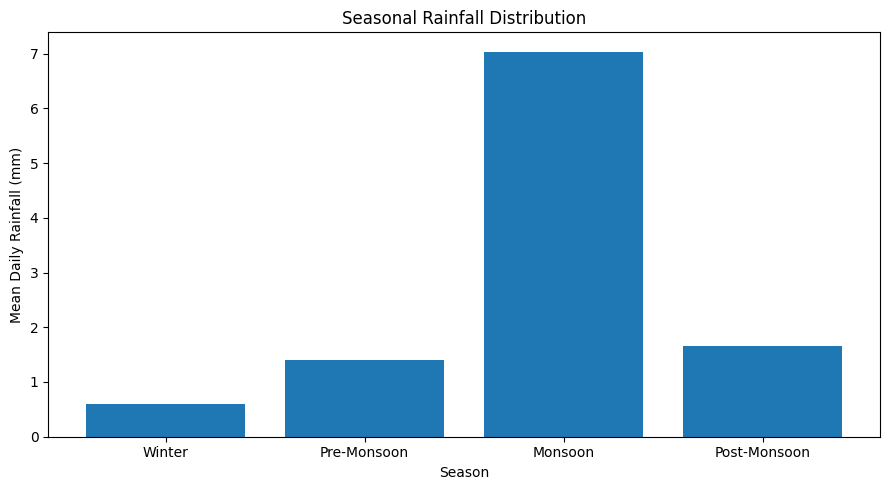

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(
    season_stats.index,
    season_stats["Mean"]
)

plt.xlabel("Season")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.title("Seasonal Rainfall Distribution")

plt.tight_layout()
plt.show()

### Solar Nakshatra Analysis

In [16]:
solar_nakshatra_stats = (
    master_df
    .groupby("solar_nakshatra")["Rainfall_mm"]
    .agg(
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Total="sum",
        Wet_Days=lambda x: (x > 0).sum(),
        Days="count"
    )
)

solar_nakshatra_stats = (
    solar_nakshatra_stats
    .sort_values("Mean", ascending=False)
)

solar_nakshatra_stats

,Mean,Median,Std_Dev,Total,Wet_Days,Days
solar_nakshatra,,,,,,
Pushya,9.297169,9.26,2.698201,16223.56,1745,1745
Punarvasu,9.076125,8.98,2.857255,15855.99,1747,1747
Ashlesha,8.441404,8.27,2.675993,14671.16,1738,1738
Ardra,7.631236,7.40,2.880909,13331.77,1747,1747
Magha,7.454719,7.38,2.419392,12889.21,1729,1729
Purva Phalguni,6.473762,6.36,2.467709,11115.45,1717,1717
Mrigashira,5.406980,5.08,2.546237,9435.18,1745,1745
Uttara Phalguni,5.210469,4.99,2.486484,8894.27,1707,1707
Hasta,3.515387,2.98,2.310976,5951.55,1693,1693


Ordered Nakshatra Visualization

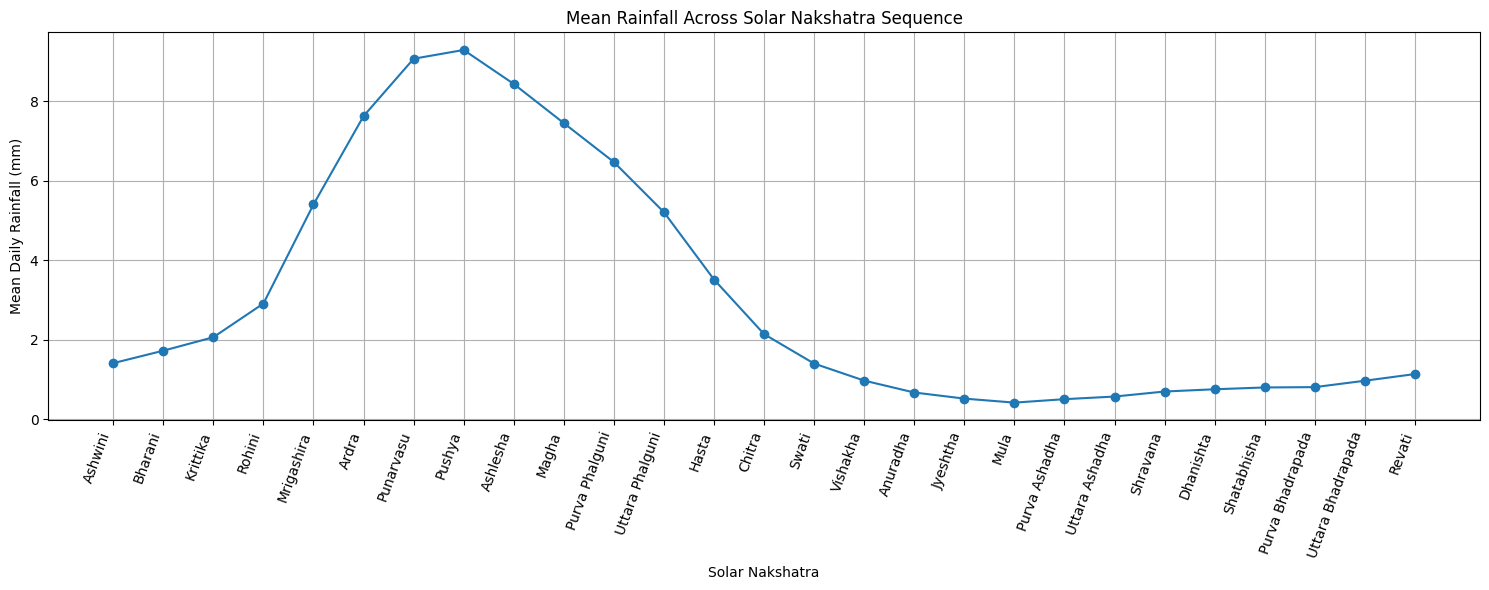

In [17]:
nakshatra_order = [
    "Ashwini", "Bharani", "Krittika", "Rohini",
    "Mrigashira", "Ardra", "Punarvasu", "Pushya",
    "Ashlesha", "Magha", "Purva Phalguni",
    "Uttara Phalguni", "Hasta", "Chitra", "Swati",
    "Vishakha", "Anuradha", "Jyeshtha", "Mula",
    "Purva Ashadha", "Uttara Ashadha", "Shravana",
    "Dhanishta", "Shatabhisha", "Purva Bhadrapada",
    "Uttara Bhadrapada", "Revati"
]

nakshatra_ordered = (
    master_df
    .groupby("solar_nakshatra")["Rainfall_mm"]
    .mean()
    .reindex(nakshatra_order)
)

plt.figure(figsize=(15, 6))

plt.plot(
    range(len(nakshatra_ordered)),
    nakshatra_ordered.values,
    marker="o"
)

plt.xlabel("Solar Nakshatra")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.title(
    "Mean Rainfall Across Solar Nakshatra Sequence"
)

plt.xticks(
    range(len(nakshatra_order)),
    nakshatra_order,
    rotation=70,
    ha="right"
)

plt.grid(True)

plt.tight_layout()
plt.show()

Solar Nakshatra Pada Analysis

In [18]:
pada_stats = (
    master_df
    .groupby("solar_nakshatra_pada")["Rainfall_mm"]
    .agg(
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Days="count"
    )
    .sort_index()
)

pada_stats

,Mean,Median,Std_Dev,Days
solar_nakshatra_pada,,,,
1,3.100866,1.57,3.469073,11404
2,3.133194,1.58,3.509013,11420
3,3.157470,1.65,3.492871,11409
4,3.125725,1.61,3.463593,11423


Lunar Nakshatra Analysis

In [19]:
lunar_nakshatra_stats = (
    master_df
    .groupby("lunar_nakshatra")["Rainfall_mm"]
    .agg(
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Days="count"
    )
    .sort_values("Mean", ascending=False)
)

lunar_nakshatra_stats

,Mean,Median,Std_Dev,Days
lunar_nakshatra,,,,
Hasta,3.194374,1.650,3.558803,1701
Anuradha,3.188807,1.600,3.589546,1693
Uttara Phalguni,3.172989,1.620,3.532802,1693
Ashwini,3.168541,1.640,3.537551,1693
Revati,3.165563,1.635,3.492864,1688
Swati,3.158980,1.640,3.537728,1676
Purva Bhadrapada,3.158160,1.580,3.563235,1685
Jyeshtha,3.156133,1.585,3.600563,1686
Vishakha,3.153316,1.610,3.550961,1692


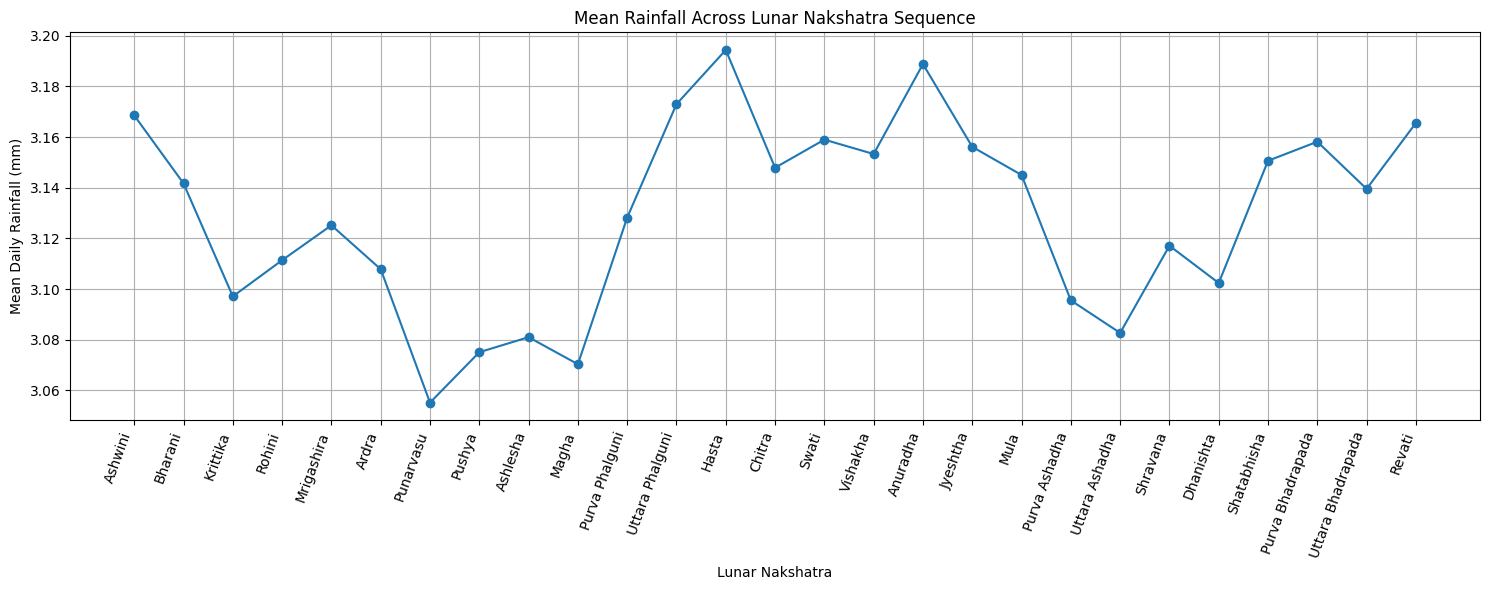

In [20]:
lunar_nakshatra_ordered = (
    master_df
    .groupby("lunar_nakshatra")["Rainfall_mm"]
    .mean()
    .reindex(nakshatra_order)
)

plt.figure(figsize=(15, 6))

plt.plot(
    range(len(nakshatra_order)),
    lunar_nakshatra_ordered.values,
    marker="o"
)

plt.xlabel("Lunar Nakshatra")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.title(
    "Mean Rainfall Across Lunar Nakshatra Sequence"
)

plt.xticks(
    range(len(nakshatra_order)),
    nakshatra_order,
    rotation=70,
    ha="right"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# Nakshatra * Month Interaction

In [21]:
nakshatra_month = pd.pivot_table(
    master_df,
    index="solar_nakshatra",
    columns="Month",
    values="Rainfall_mm",
    aggfunc="mean"
).reindex(nakshatra_order)

nakshatra_month

Month,1,2,3,4,5,6,7,8,9,10,11,12
solar_nakshatra,,,,,,,,,,,,
Ashwini,NaN,NaN,NaN,1.409222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bharani,NaN,NaN,NaN,1.516541,1.785648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Krittika,NaN,NaN,NaN,NaN,2.062023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rohini,NaN,NaN,NaN,NaN,2.409286,3.365044,NaN,NaN,NaN,NaN,NaN,NaN
Mrigashira,NaN,NaN,NaN,NaN,NaN,5.406980,NaN,NaN,NaN,NaN,NaN,NaN
Ardra,NaN,NaN,NaN,NaN,NaN,7.177754,8.385427,NaN,NaN,NaN,NaN,NaN
Punarvasu,NaN,NaN,NaN,NaN,NaN,NaN,9.076125,NaN,NaN,NaN,NaN,NaN
Pushya,NaN,NaN,NaN,NaN,NaN,NaN,9.365428,8.929121,NaN,NaN,NaN,NaN
Ashlesha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.441404,NaN,NaN,NaN,NaN


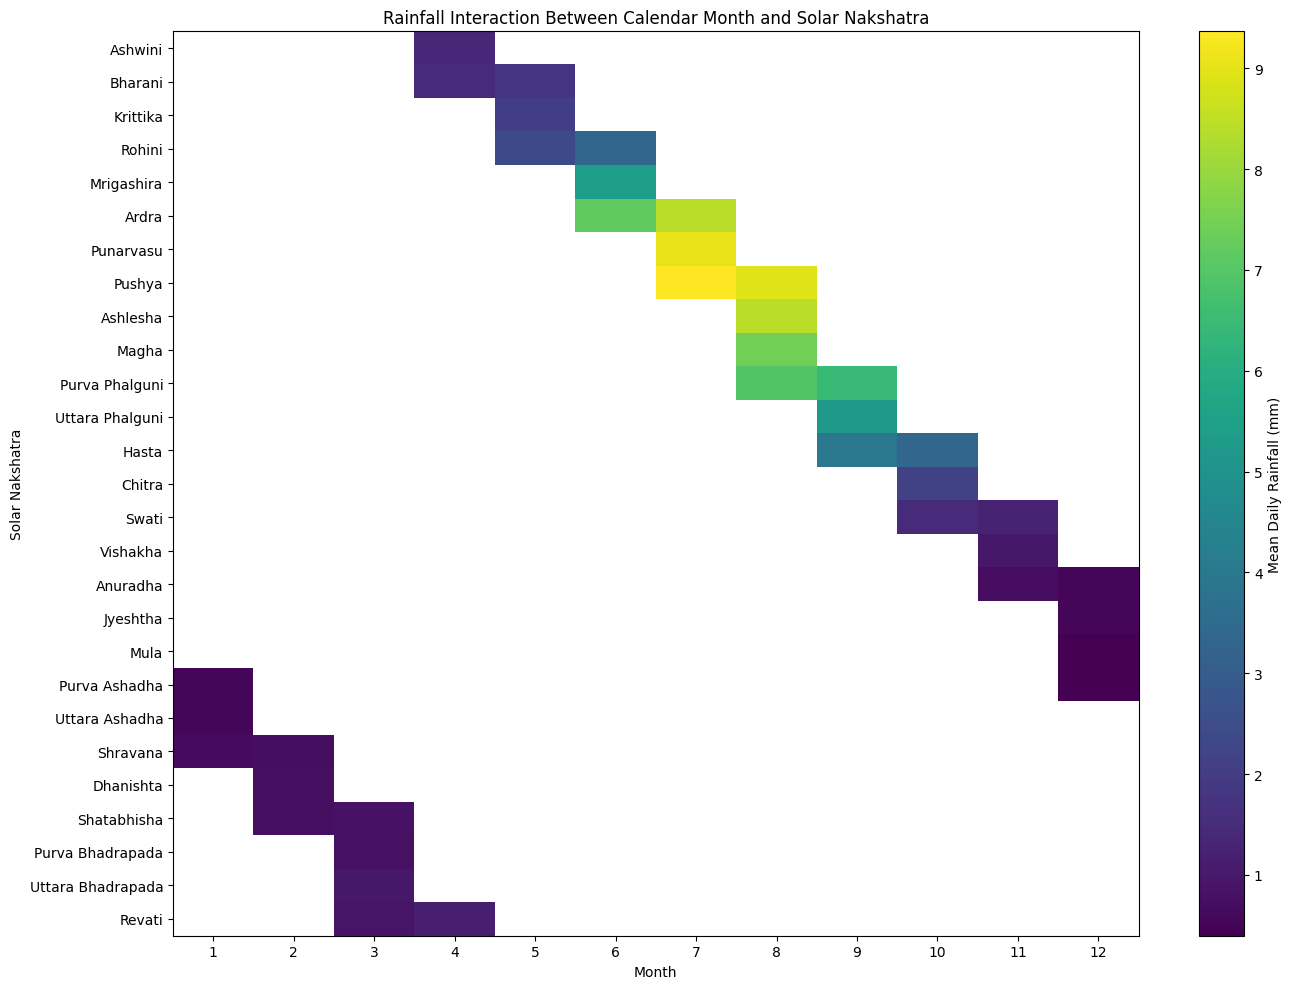

In [22]:
plt.figure(figsize=(14, 10))

plt.imshow(
    nakshatra_month,
    aspect="auto"
)

plt.colorbar(
    label="Mean Daily Rainfall (mm)"
)

plt.xlabel("Month")
plt.ylabel("Solar Nakshatra")
plt.title(
    "Rainfall Interaction Between Calendar Month and Solar Nakshatra"
)

plt.xticks(
    range(12),
    range(1, 13)
)

plt.yticks(
    range(len(nakshatra_order)),
    nakshatra_order
)

plt.tight_layout()
plt.show()

This visualization will be particularly useful later when we ask:

Does Nakshatra contain information beyond the ordinary calendar month?

# Baseline vs recent climate analysis

In [23]:
era_stats = (
    master_df
    .groupby("Era")["Rainfall_mm"]
    .agg(
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Total="sum",
        Maximum="max",
        Wet_Days=lambda x: (x > 0).sum(),
        Days="count"
    )
)

era_stats

,Mean,Median,Std_Dev,Total,Maximum,Wet_Days,Days
Era,,,,,,,
Baseline (1901–1960),3.132835,1.57,3.492922,68656.08,19.13,21495,21915
Recent (1961–2025),3.126069,1.64,3.475103,74216.01,18.78,23260,23741


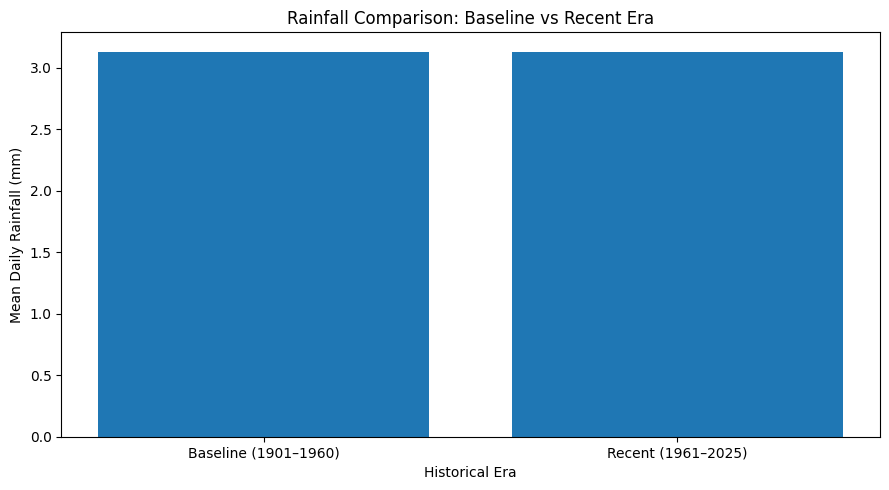

In [24]:
plt.figure(figsize=(9, 5))

plt.bar(
    era_stats.index,
    era_stats["Mean"]
)

plt.xlabel("Historical Era")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.title(
    "Rainfall Comparison: Baseline vs Recent Era"
)

plt.tight_layout()
plt.show()

# Nakshatra climate drift

Now we examine whether the rainfall associated with individual Nakshatras changed between the two periods.

In [25]:
nakshatra_era = pd.pivot_table(
    master_df,
    index="solar_nakshatra",
    columns="Era",
    values="Rainfall_mm",
    aggfunc="mean"
).reindex(nakshatra_order)

nakshatra_era["Absolute_Change"] = (
    nakshatra_era["Recent (1961–2025)"]
    -
    nakshatra_era["Baseline (1901–1960)"]
)

nakshatra_era["Percentage_Change"] = (
    nakshatra_era["Absolute_Change"]
    /
    nakshatra_era["Baseline (1901–1960)"]
    * 100
)

nakshatra_era

Era,Baseline (1901–1960),Recent (1961–2025),Absolute_Change,Percentage_Change
solar_nakshatra,,,,
Ashwini,1.364385,1.450676,0.086291,6.324519
Bharani,1.691612,1.752284,0.060672,3.586656
Krittika,1.981689,2.135938,0.154249,7.783718
Rohini,2.870370,2.949302,0.078932,2.749887
Mrigashira,5.342482,5.466571,0.124089,2.322685
Ardra,7.710596,7.557907,-0.152688,-1.980242
Punarvasu,9.110942,9.043954,-0.066988,-0.735246
Pushya,9.437416,9.168185,-0.269231,-2.852809
Ashlesha,8.341703,8.533385,0.191682,2.297880


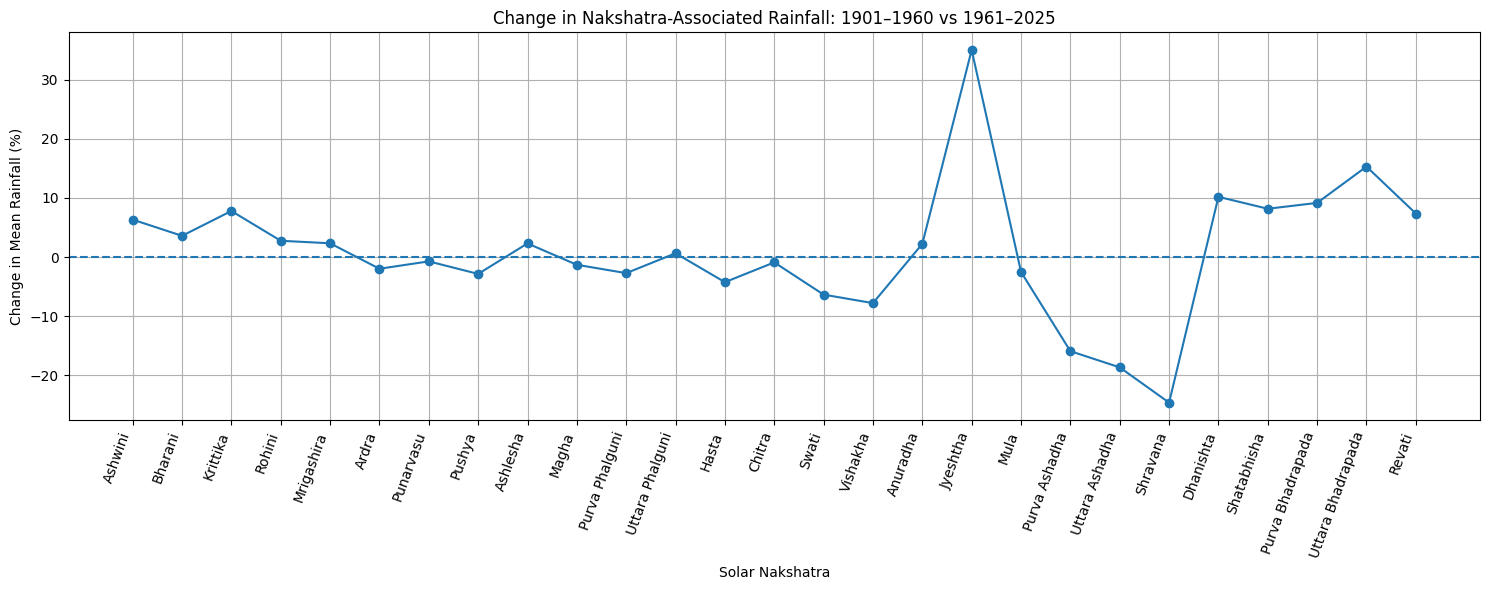

In [26]:
plt.figure(figsize=(15, 6))

plt.plot(
    range(len(nakshatra_order)),
    nakshatra_era["Percentage_Change"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Solar Nakshatra")
plt.ylabel("Change in Mean Rainfall (%)")
plt.title(
    "Change in Nakshatra-Associated Rainfall: "
    "1901–1960 vs 1961–2025"
)

plt.xticks(
    range(len(nakshatra_order)),
    nakshatra_order,
    rotation=70,
    ha="right"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# Extreme Rainfall Analysis

In [27]:
q95 = master_df["Rainfall_mm"].quantile(0.95)
q99 = master_df["Rainfall_mm"].quantile(0.99)

print(f"95th percentile: {q95:.2f} mm")
print(f"99th percentile: {q99:.2f} mm")

extreme_days = master_df[
    master_df["Rainfall_mm"] >= q99
].copy()

print(
    "Number of extreme rainfall days:",
    len(extreme_days)
)

95th percentile: 10.40 mm
99th percentile: 13.26 mm
Number of extreme rainfall days: 458


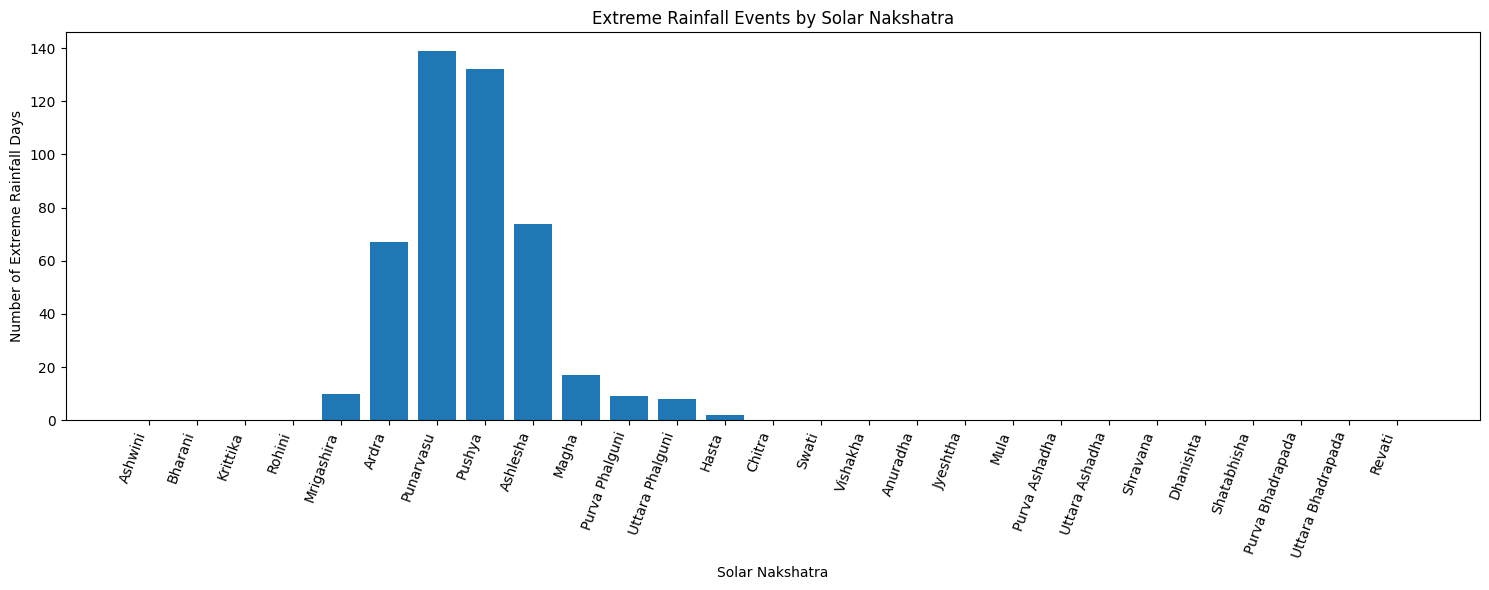

In [28]:
extreme_nakshatra = (
    extreme_days
    .groupby("solar_nakshatra")
    .size()
    .reindex(nakshatra_order)
    .fillna(0)
)

plt.figure(figsize=(15, 6))

plt.bar(
    extreme_nakshatra.index,
    extreme_nakshatra.values
)

plt.xlabel("Solar Nakshatra")
plt.ylabel("Number of Extreme Rainfall Days")
plt.title(
    "Extreme Rainfall Events by Solar Nakshatra"
)

plt.xticks(
    rotation=70,
    ha="right"
)

plt.tight_layout()
plt.show()

Rainfall Variability through time

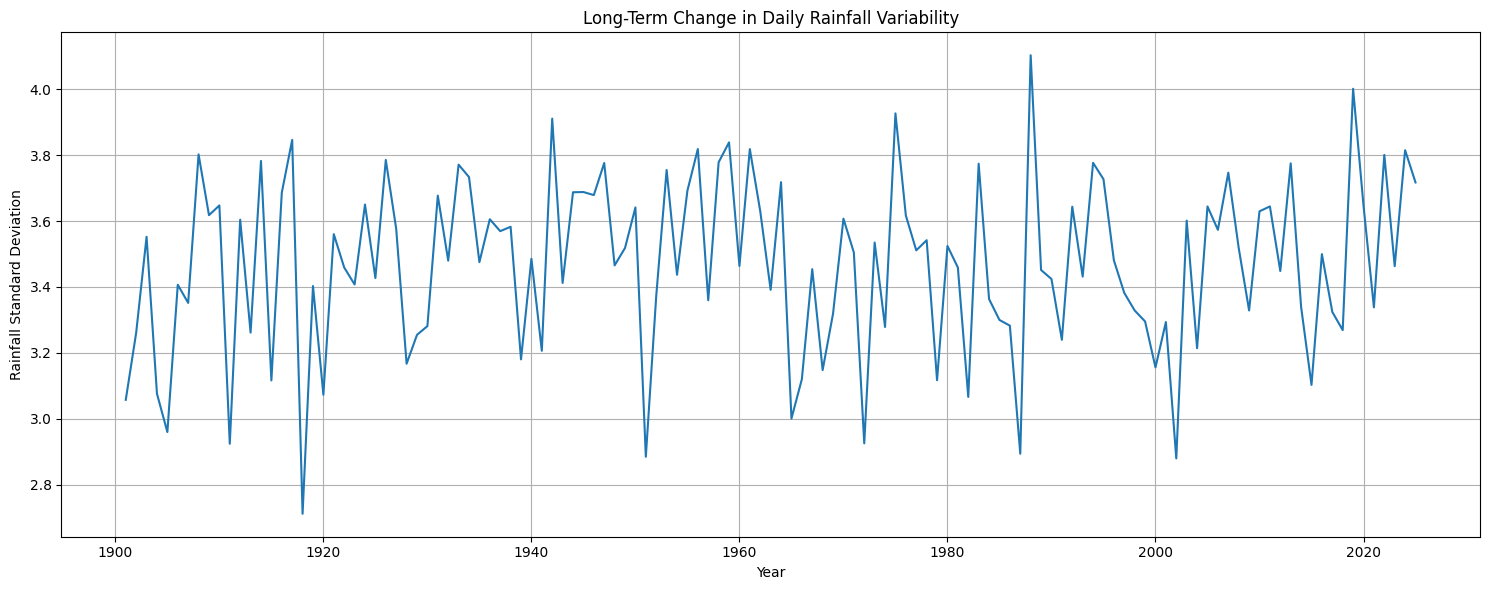

In [29]:
annual_variability = (
    master_df
    .groupby("Year")["Rainfall_mm"]
    .agg(
        Mean="mean",
        Std_Dev="std",
        Maximum="max"
    )
)

plt.figure(figsize=(15, 6))

plt.plot(
    annual_variability.index,
    annual_variability["Std_Dev"]
)

plt.xlabel("Year")
plt.ylabel("Rainfall Standard Deviation")
plt.title(
    "Long-Term Change in Daily Rainfall Variability"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# Rainfall vs Solar Longitude

Instead of only treating Nakshatra as categorical, we can investigate the underlying continuous astronomical variable.

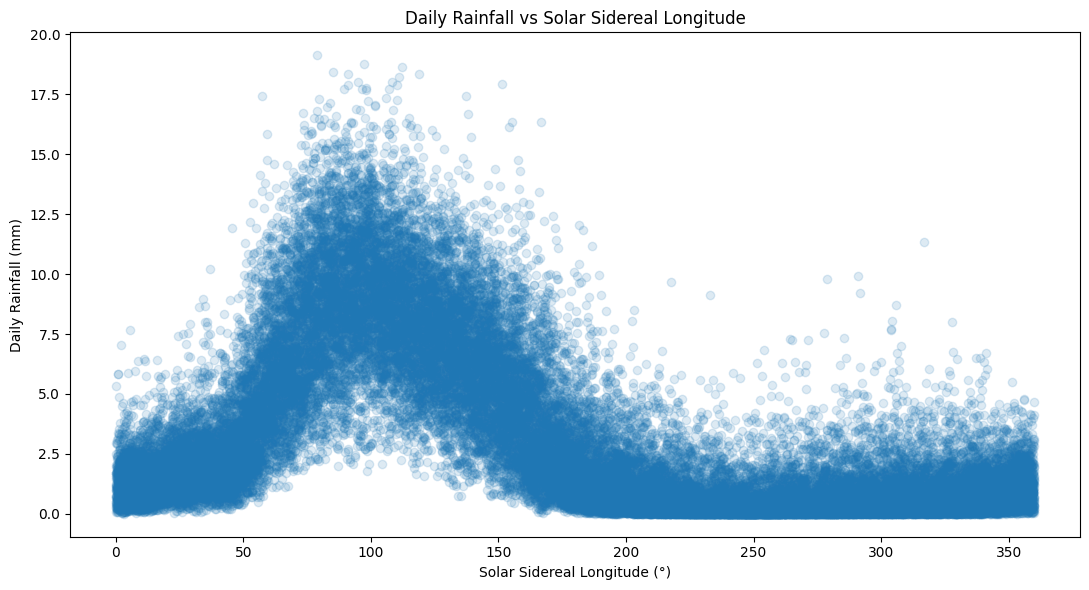

In [30]:
plt.figure(figsize=(11, 6))

plt.scatter(
    master_df["sun_sidereal_longitude"],
    master_df["Rainfall_mm"],
    alpha=0.15
)

plt.xlabel("Solar Sidereal Longitude (°)")
plt.ylabel("Daily Rainfall (mm)")
plt.title(
    "Daily Rainfall vs Solar Sidereal Longitude"
)

plt.tight_layout()
plt.show()

# Correlation Analysis

In [31]:
numeric_columns = [
    "Rainfall_mm",
    "sun_sidereal_longitude",
    "solar_nakshatra_pada",
    "moon_sidereal_longitude",
    "lunar_nakshatra_pada",
    "Year",
    "Month",
    "Day_of_Year"
]

correlation_matrix = (
    master_df[numeric_columns]
    .corr()
)

correlation_matrix

,Rainfall_mm,sun_sidereal_longitude,solar_nakshatra_pada,moon_sidereal_longitude,lunar_nakshatra_pada,Year,Month,Day_of_Year
Rainfall_mm,1.000000,-0.481887,0.003170,0.002922,0.007534,0.009055,0.182135,0.180011
sun_sidereal_longitude,-0.481887,1.000000,0.035939,-0.001566,0.001407,0.000031,-0.227036,-0.227427
solar_nakshatra_pada,0.003170,0.035939,1.000000,-0.005987,-0.001568,-0.000014,0.002079,0.000453
moon_sidereal_longitude,0.002922,-0.001566,-0.005987,1.000000,0.033371,-0.001463,0.001297,0.001443
lunar_nakshatra_pada,0.007534,0.001407,-0.001568,0.033371,1.000000,0.000145,-0.001400,-0.001450
Year,0.009055,0.000031,-0.000014,-0.001463,0.000145,1.000000,-0.000025,0.000033
Month,0.182135,-0.227036,0.002079,0.001297,-0.001400,-0.000025,1.000000,0.996501
Day_of_Year,0.180011,-0.227427,0.000453,0.001443,-0.001450,0.000033,0.996501,1.000000


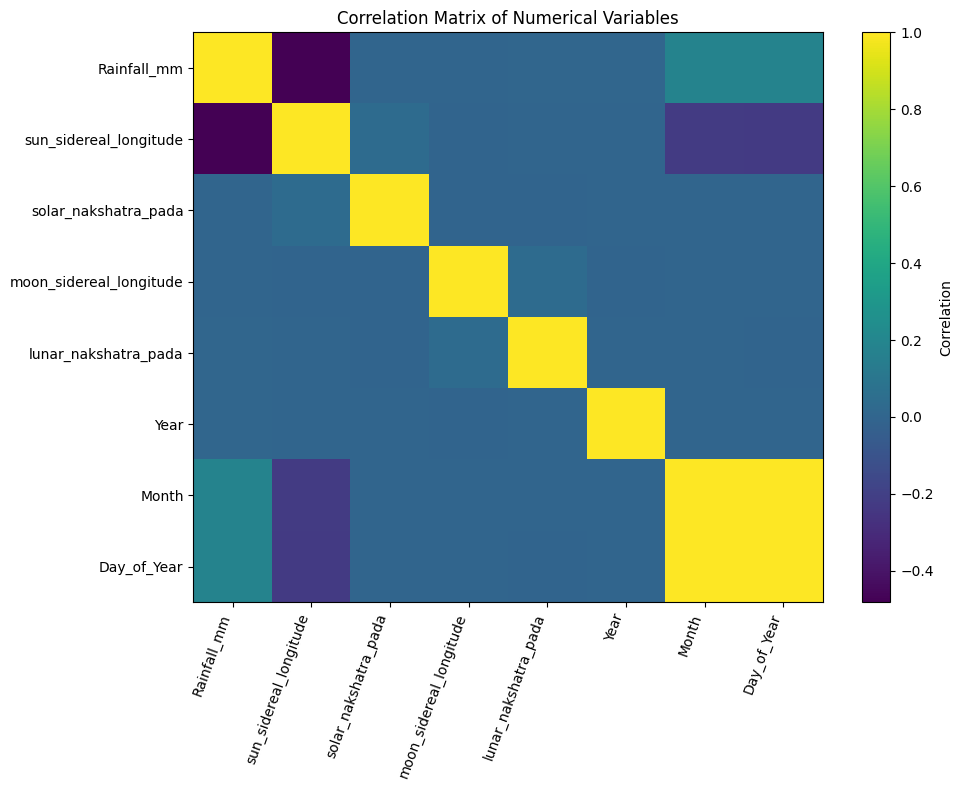

In [32]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=70,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

Key Exploratory Findings Table

In [33]:
top_nakshatras = (
    solar_nakshatra_stats
    .sort_values("Mean", ascending=False)
    .head(5)
)

bottom_nakshatras = (
    solar_nakshatra_stats
    .sort_values("Mean", ascending=True)
    .head(5)

)

print("Top 5 Nakshatras by Mean Rainfall")
display(top_nakshatras)

print("\nBottom 5 Nakshatras by Mean Rainfall")
display(bottom_nakshatras)

Top 5 Nakshatras by Mean Rainfall


,Mean,Median,Std_Dev,Total,Wet_Days,Days
solar_nakshatra,,,,,,
Pushya,9.297169,9.26,2.698201,16223.56,1745,1745
Punarvasu,9.076125,8.98,2.857255,15855.99,1747,1747
Ashlesha,8.441404,8.27,2.675993,14671.16,1738,1738
Ardra,7.631236,7.40,2.880909,13331.77,1747,1747
Magha,7.454719,7.38,2.419392,12889.21,1729,1729



Bottom 5 Nakshatras by Mean Rainfall


,Mean,Median,Std_Dev,Total,Wet_Days,Days
solar_nakshatra,,,,,,
Mula,0.415201,0.17,0.673050,680.10,1444,1638
Purva Ashadha,0.501831,0.19,0.807454,819.49,1493,1633
Jyeshtha,0.516319,0.21,0.797737,845.73,1499,1638
Uttara Ashadha,0.567972,0.27,0.846699,929.77,1537,1637
Anuradha,0.669775,0.32,0.913595,1103.79,1574,1648


# Export EDA tables

In [40]:
EDA_DIR = Path("/content/eda_results")
EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

monthly_stats.to_csv(
    EDA_DIR / "monthly_rainfall_statistics.csv",
    index=False
)

season_stats.to_csv(
    EDA_DIR / "seasonal_rainfall_statistics.csv"
)

solar_nakshatra_stats.to_csv(
    EDA_DIR / "solar_nakshatra_rainfall_statistics.csv"
)

lunar_nakshatra_stats.to_csv(
    EDA_DIR / "lunar_nakshatra_rainfall_statistics.csv"
)

era_stats.to_csv(
    EDA_DIR / "era_rainfall_statistics.csv"
)

nakshatra_era.to_csv(
    EDA_DIR / "nakshatra_era_comparison.csv"
)

correlation_matrix.to_csv(
    EDA_DIR / "correlation_matrix.csv"
)

print("EDA tables exported successfully.")

EDA tables exported successfully.


Final EDA Summary

In [41]:
print("=" * 75)
print("EDA SUMMARY")
print("=" * 75)

print(f"Study period              : "
      f"{master_df['Year'].min()}–{master_df['Year'].max()}")

print(f"Daily observations        : "
      f"{len(master_df):,}")

print(f"Solar Nakshatras          : "
      f"{master_df['solar_nakshatra'].nunique()}")

print(f"Lunar Nakshatras          : "
      f"{master_df['lunar_nakshatra'].nunique()}")

print(f"Mean daily rainfall       : "
      f"{master_df['Rainfall_mm'].mean():.3f} mm")

print(f"Median daily rainfall     : "
      f"{master_df['Rainfall_mm'].median():.3f} mm")

print(f"Maximum daily rainfall    : "
      f"{master_df['Rainfall_mm'].max():.3f} mm")

print(f"95th percentile rainfall  : "
      f"{q95:.3f} mm")

print(f"99th percentile rainfall  : "
      f"{q99:.3f} mm")

print("=" * 75)
print("EDA COMPLETE")
print("=" * 75)

EDA SUMMARY
Study period              : 1901–2025
Daily observations        : 45,656
Solar Nakshatras          : 27
Lunar Nakshatras          : 27
Mean daily rainfall       : 3.129 mm
Median daily rainfall     : 1.600 mm
Maximum daily rainfall    : 19.130 mm
95th percentile rainfall  : 10.400 mm
99th percentile rainfall  : 13.260 mm
EDA COMPLETE
